In [1]:
import numpy as np
import pandas as pd 
from scipy import stats 
import os
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df_item = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_order_items_dataset.csv")
df_reviews = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_order_reviews_dataset.csv")
df_orders = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_orders_dataset.csv")
df_products = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_products_dataset.csv")
df_geolocation = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_geolocation_dataset.csv")
df_sellers = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_sellers_dataset.csv")
df_order_pay = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_order_payments_dataset.csv")
df_customers = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\olist_customers_dataset.csv")
df_category = pd.read_csv(r"C:\\FACULDADE\tcc\EDA\archive\product_category_name_translation.csv")

In [4]:
df_train = df_orders.merge(df_item, on='order_id', how='left')
df_train = df_train.merge(df_order_pay, on='order_id', how='outer', validate='m:m')
df_train = df_train.merge(df_reviews, on='order_id', how='outer')
df_train = df_train.merge(df_products, on='product_id', how='outer')
df_train = df_train.merge(df_customers, on='customer_id', how='outer')
df_train = df_train.merge(df_sellers, on='seller_id', how='outer')

print(df_train.shape)

(119143, 39)


In [5]:
df_train.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,d455a8cb295653b55abda06d434ab492,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,1.0,a2ff5a97bf95719e38ea2e3b4105bce8,...,40.0,43.0,36.0,3c7e305796add66698959fc7ad176f6b,87502,umuarama,PR,9080.0,santo andre,SP
1,7f39ba4c9052be115350065d07583cac,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,1.0,a2ff5a97bf95719e38ea2e3b4105bce8,...,40.0,43.0,36.0,9de5797cddb92598755a0f76383ddbbb,35490,entre rios de minas,MG,9080.0,santo andre,SP
2,9dc8d1a6f16f1b89874c29c9d8d30447,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,1.0,a2ff5a97bf95719e38ea2e3b4105bce8,...,40.0,43.0,36.0,9915eb9f74b6c11aaf04833f65b00e93,38600,paracatu,MG,9080.0,santo andre,SP
3,0f548bd29148ebc519d6495e37a284e1,015faf9ec36eccd957c0f2782aab09a4,delivered,2017-09-03 08:06:30,2017-09-03 08:25:50,2017-09-04 22:03:06,2017-09-08 16:26:55,2017-09-27 00:00:00,1.0,08574b074924071f4e201e151b152b4e,...,42.0,12.0,39.0,dce323533e45e74d215e0fe7fb114118,24710,sao goncalo,RJ,29156.0,cariacica,ES
4,0f548bd29148ebc519d6495e37a284e1,015faf9ec36eccd957c0f2782aab09a4,delivered,2017-09-03 08:06:30,2017-09-03 08:25:50,2017-09-04 22:03:06,2017-09-08 16:26:55,2017-09-27 00:00:00,2.0,08574b074924071f4e201e151b152b4e,...,42.0,12.0,39.0,dce323533e45e74d215e0fe7fb114118,24710,sao goncalo,RJ,29156.0,cariacica,ES


## Quantidade de Clientes por Estado

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\1272133806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='customer_state', order=df_train['customer_state'].value_counts().index, palette='viridis')


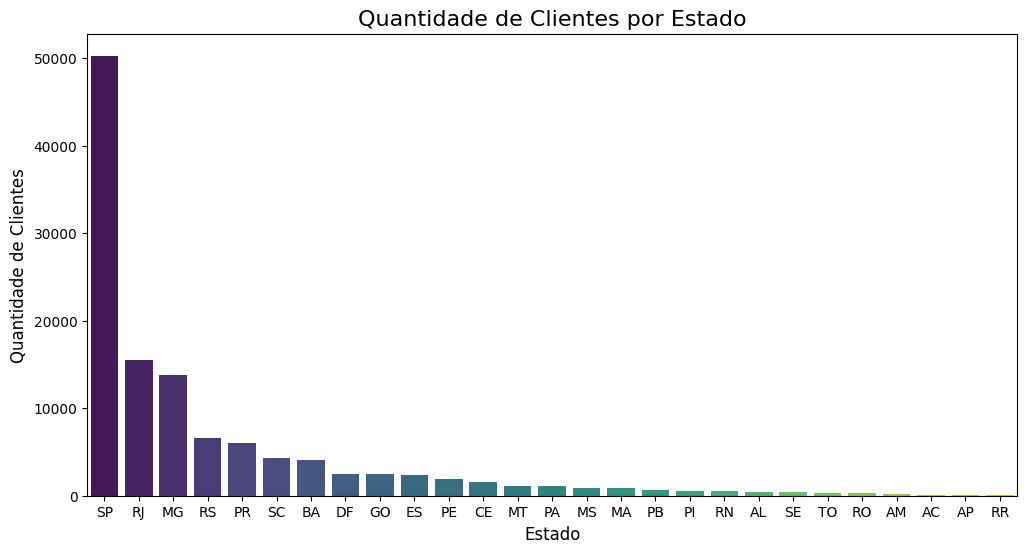

In [6]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='customer_state', order=df_train['customer_state'].value_counts().index, palette='viridis')
plt.title('Quantidade de Clientes por Estado', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.show()

## Quantidade de Vendedores por Estado

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\2670292818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='seller_state', order=df_train['seller_state'].value_counts().index, palette='viridis')


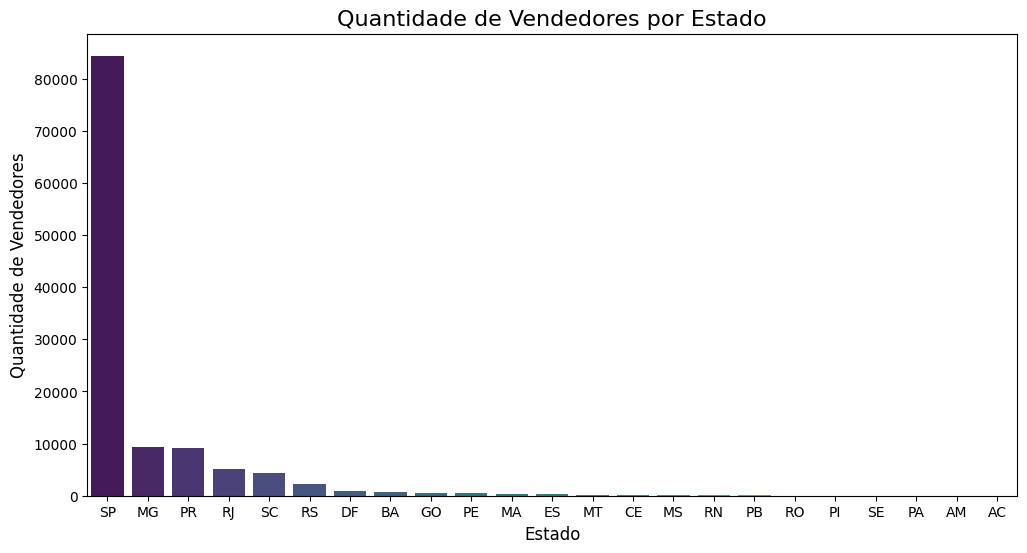

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_train, x='seller_state', order=df_train['seller_state'].value_counts().index, palette='viridis')
plt.title('Quantidade de Vendedores por Estado', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Quantidade de Vendedores', fontsize=12)
plt.show()

## Tempo Médio de Entrega por Estado do Cliente

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\3681130981.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tempo_por_estado, x='customer_state', y='delivery_time_days', palette='magma')


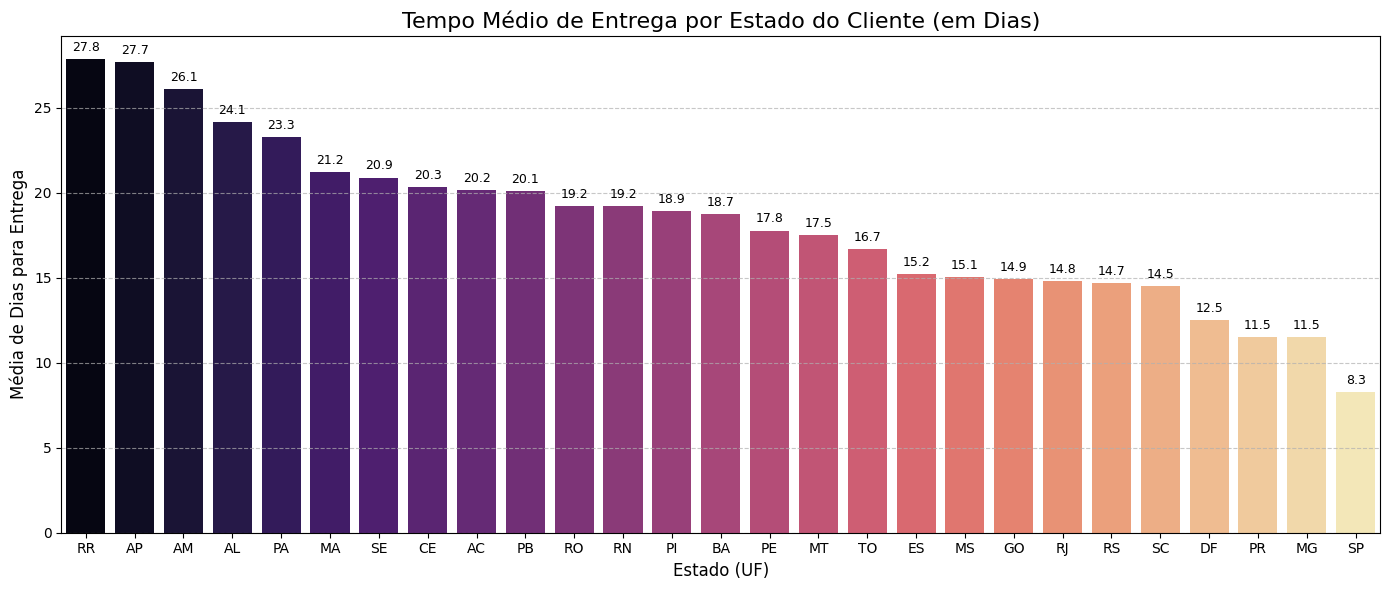

In [19]:
# Calculando o tempo de entrega em dias
# Convertemos para datetime caso ainda não esteja
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])
df_train['order_purchase_timestamp'] = pd.to_datetime(df_train['order_purchase_timestamp'])

# Coluna com o tempo até o cliente receber o pacote
df_train['delivery_time_days'] = (df_train['order_delivered_customer_date'] - df_train['order_purchase_timestamp']).dt.days

# Removendo valores nulos onde não houve entrega
df_entrega_estado = df_train.dropna(subset=['delivery_time_days', 'customer_state']).copy()

# Agrupando pelo estado do cliente para calcular a média de dias de entrega
tempo_por_estado = df_entrega_estado.groupby('customer_state')['delivery_time_days'].mean().reset_index()
tempo_por_estado.sort_values(by='delivery_time_days', ascending=False, inplace=True)

# Plotando o gráfico de barras
plt.figure(figsize=(14, 6))
sns.barplot(data=tempo_por_estado, x='customer_state', y='delivery_time_days', palette='magma')

plt.title('Tempo Médio de Entrega por Estado do Cliente (em Dias)', fontsize=16)
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Média de Dias para Entrega', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os rótulos em cima das barras para clareza
for index, value in enumerate(tempo_por_estado['delivery_time_days']):
    plt.text(index, value + 0.3, f'{value:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Avaliação X Total de itens de um mesmo pedido

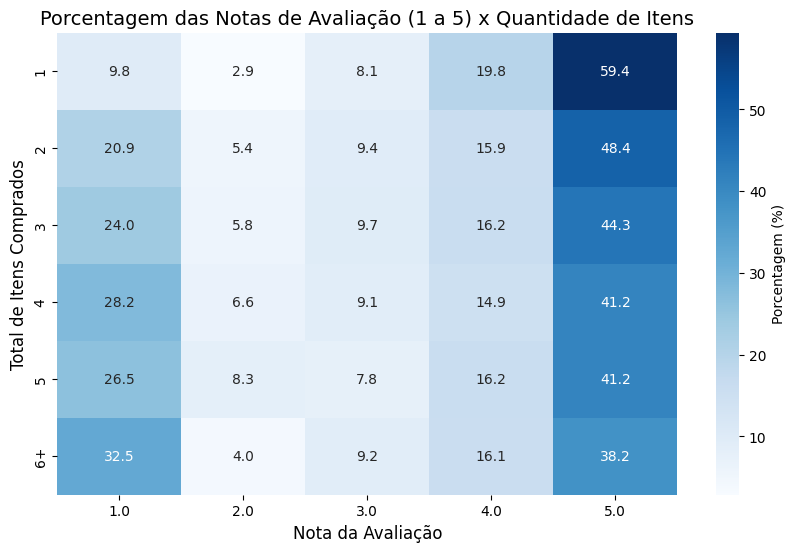

review_score,1.0,2.0,3.0,4.0,5.0
total_items_group,,,,,
1,9.83,2.87,8.12,19.80,59.38
2,20.87,5.42,9.40,15.94,48.37
3,24.00,5.77,9.69,16.23,44.31
4,28.17,6.64,9.05,14.89,41.25
5,26.47,8.33,7.84,16.18,41.18
6+,32.53,4.02,9.24,16.06,38.15


In [8]:
# Agrupando por order_id para pegar o total de itens e a nota principal da avaliação
order_stats = df_train.groupby('order_id').agg(
    total_items=('order_item_id', 'max'),
    review_score=('review_score', 'first')
).dropna()

# Agrupando compras com mais de 5 itens na categoria "6+"
order_stats['total_items_group'] = order_stats['total_items'].apply(lambda x: str(int(x)) if x <= 5 else '6+')

# Criando tabela cruzada (crosstab) convertida para porcentagem nas linhas (normalize='index')
cross_tab = pd.crosstab(order_stats['total_items_group'], order_stats['review_score'], normalize='index') * 100

# Ordenando o índice para os gráficos
cross_tab = cross_tab.reindex(['1', '2', '3', '4', '5', '6+'])

# Plotando um mapa de calor (heatmap) para facilitar a visualização
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, cmap="Blues", fmt=".1f", cbar_kws={'label': 'Porcentagem (%)'})
plt.title('Porcentagem das Notas de Avaliação (1 a 5) x Quantidade de Itens', fontsize=14)
plt.xlabel('Nota da Avaliação', fontsize=12)
plt.ylabel('Total de Itens Comprados', fontsize=12)
plt.show()

# Para visualizar a tabela correspondente no estilo DataFrame:
display(cross_tab.round(2))

A maioria que teve avaliação máxima, é porque comprou apenas 1 produto

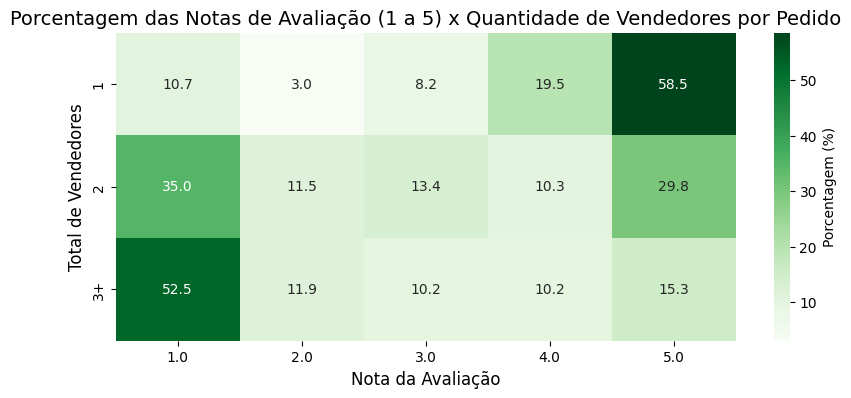

review_score,1.0,2.0,3.0,4.0,5.0
total_sellers_group,,,,,
1,10.72,3.03,8.18,19.54,58.54
2,35.02,11.54,13.36,10.29,29.79
3+,52.54,11.86,10.17,10.17,15.25


In [10]:
# Agrupando por order_id para pegar o total de vendedores únicos e a nota principal da avaliação
seller_stats = df_train.groupby('order_id').agg(
    total_sellers=('seller_id', 'nunique'),
    review_score=('review_score', 'first')
).dropna()

# Agrupando compras com 3 ou mais vendedores na categoria "3+"
seller_stats['total_sellers_group'] = seller_stats['total_sellers'].apply(lambda x: str(int(x)) if x <= 2 else '3+')

# Criando tabela cruzada (crosstab) convertida para porcentagem nas linhas (normalize='index')
cross_tab_sellers = pd.crosstab(seller_stats['total_sellers_group'], seller_stats['review_score'], normalize='index') * 100

# Ordenando o índice para os gráficos
cross_tab_sellers = cross_tab_sellers.reindex(['1', '2', '3+'])

# Plotando um mapa de calor (heatmap) focado na quantidade de vendedores
plt.figure(figsize=(10, 4))
sns.heatmap(cross_tab_sellers, annot=True, cmap="Greens", fmt=".1f", cbar_kws={'label': 'Porcentagem (%)'})
plt.title('Porcentagem das Notas de Avaliação (1 a 5) x Quantidade de Vendedores por Pedido', fontsize=14)
plt.xlabel('Nota da Avaliação', fontsize=12)
plt.ylabel('Total de Vendedores', fontsize=12)
plt.show()

# Exibindo a tabela para facilitar a leitura
display(cross_tab_sellers.round(2))

## Quantidade de compras X Mês

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\44814356.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


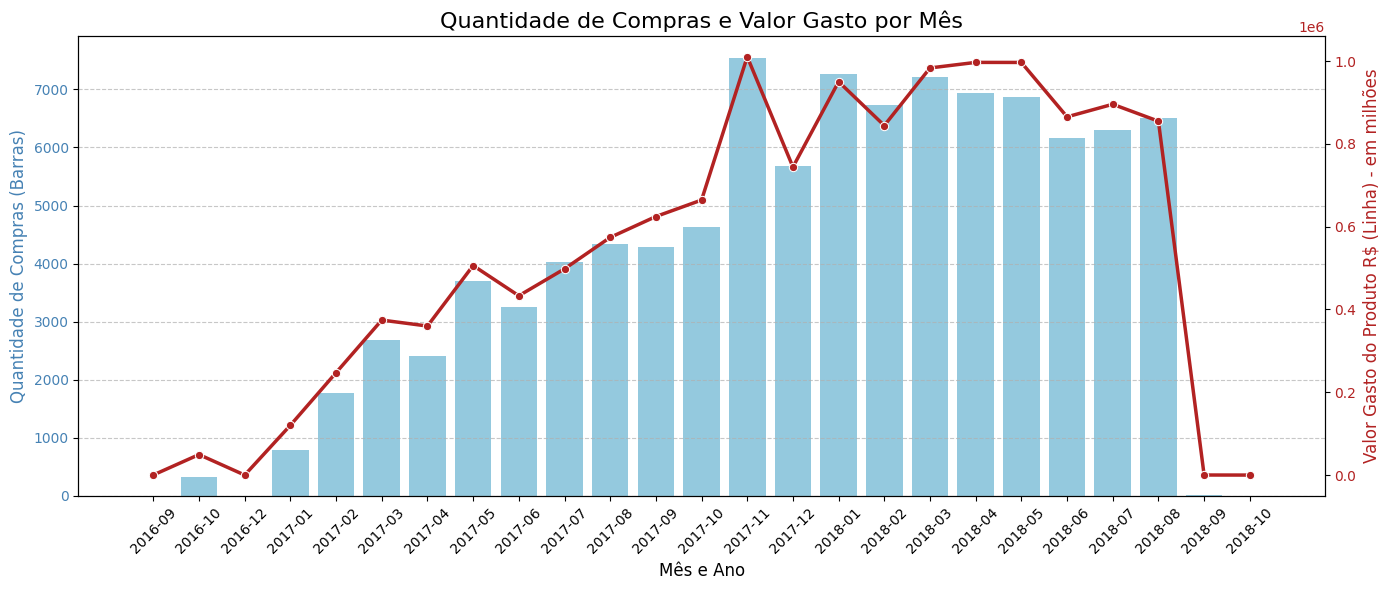

In [21]:
# Convertendo a coluna de data para o tipo datetime
df_train['order_purchase_timestamp'] = pd.to_datetime(df_train['order_purchase_timestamp'])

# Criando uma coluna com o ano e o mês (formato AAAA-MM)
df_train['year_month'] = df_train['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 1. Contando a quantidade de pedidos únicos por mês
compras_por_mes = df_train.groupby('year_month')['order_id'].nunique().reset_index()
compras_por_mes.rename(columns={'order_id': 'quantidade_compras'}, inplace=True)

# 2. Calculando o valor gasto por mês (receita)
# Como fizemos merges que podem duplicar linhas, pegamos itens únicos para ter o preço real
itens_unicos = df_train.drop_duplicates(subset=['order_id', 'order_item_id'])
valor_por_mes = itens_unicos.groupby('year_month')['price'].sum().reset_index()
valor_por_mes.rename(columns={'price': 'valor_gasto'}, inplace=True)

# Mesclando as variáveis
df_plot = pd.merge(compras_por_mes, valor_por_mes, on='year_month')

# Plotando gráfico com eixos duplos (Barras + Linhas)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo Principal (Barras) - Quantidade de Compras
sns.barplot(data=df_plot, x='year_month', y='quantidade_compras', color='skyblue', ax=ax1)
ax1.set_xlabel('Mês e Ano', fontsize=12)
ax1.set_ylabel('Quantidade de Compras (Barras)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Eixo Secundário (Linha) - Valor Gasto
ax2 = ax1.twinx()
sns.lineplot(data=df_plot, x='year_month', y='valor_gasto', marker='o', color='firebrick', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Valor Gasto do Produto R$ (Linha) - em milhões', fontsize=12, color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

plt.title('Quantidade de Compras e Valor Gasto por Mês', fontsize=16)
plt.tight_layout()
plt.show()

## Quantidade de atrasos por mês

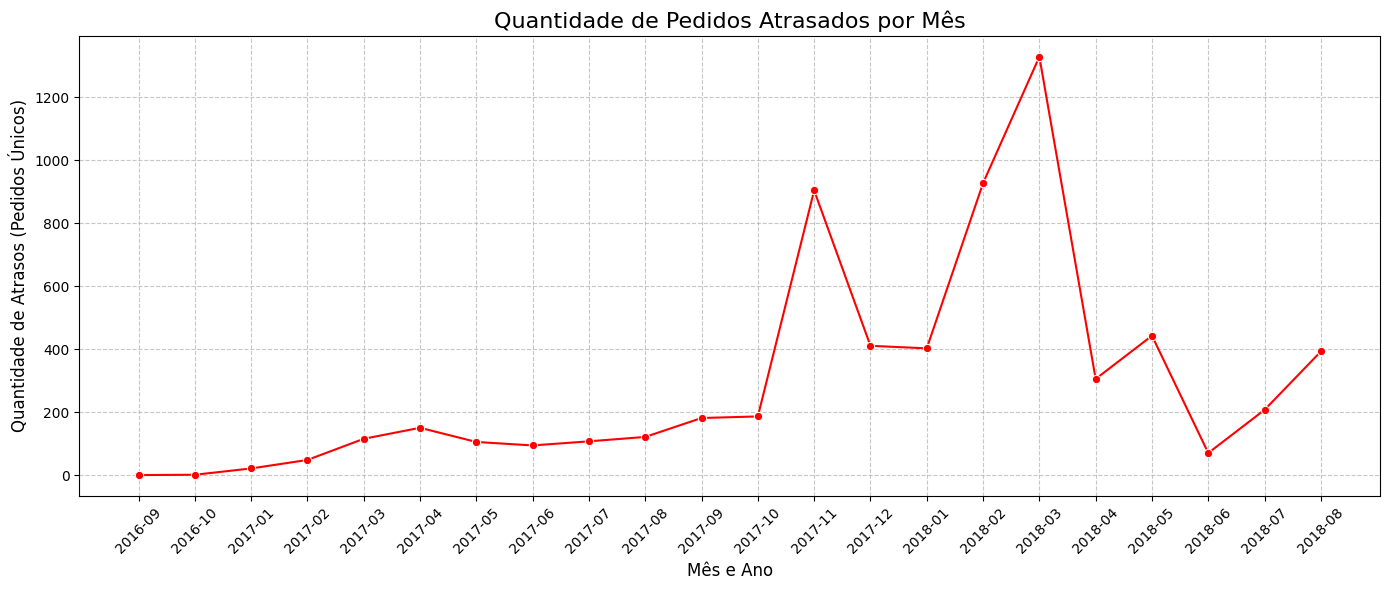

In [16]:
# Convertendo as datas para datetime (caso ainda não estejam como datetime no estado atual da memória)
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])
df_train['order_estimated_delivery_date'] = pd.to_datetime(df_train['order_estimated_delivery_date'])

# Marcando os pedidos que tiveram atraso (dias de diferença > 0)
df_train['is_delayed'] = (df_train['order_delivered_customer_date'] - df_train['order_estimated_delivery_date']).dt.days > 0

# Filtrando apenas os pedidos atrasados e agrupando por mês
atrasos_por_mes = df_train[df_train['is_delayed']].groupby('year_month')['order_id'].nunique().reset_index()
atrasos_por_mes.rename(columns={'order_id': 'quantidade_atrasos'}, inplace=True)

# Plotando o gráfico de linhas (em vermelho para destacar que são atrasos)
plt.figure(figsize=(14, 6))
sns.lineplot(data=atrasos_por_mes, x='year_month', y='quantidade_atrasos', marker='o', color='red')
plt.title('Quantidade de Pedidos Atrasados por Mês', fontsize=16)
plt.xlabel('Mês e Ano', fontsize=12)
plt.ylabel('Quantidade de Atrasos (Pedidos Únicos)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* 11/2017: Black Friday
* 12/2017: Natal
* 02/2018: Carnaval
* 03/2018: ?
* 05/2018: Greve dos caminhoneiros

In [17]:
# Identificando os meses (year_month) que tiveram mais de 200 atrasos
meses_criticos = atrasos_por_mes[atrasos_por_mes['quantidade_atrasos'] > 200]['year_month'].tolist()

print(f"Meses com mais de 200 atrasos: {meses_criticos}\n")

# Mostrando o range de datas (início e fim) das compras que originaram esses atrasos, por mês
if meses_criticos:
    for mes in meses_criticos:
        # Filtrando o dataframe de treino para pegar apenas os pedidos atrasados daquele mês
        df_atrasos_do_mes = df_train[(df_train['is_delayed']) & (df_train['year_month'] == mes)]
        
        data_min = df_atrasos_do_mes['order_purchase_timestamp'].min().strftime('%d/%m/%Y')
        data_max = df_atrasos_do_mes['order_purchase_timestamp'].max().strftime('%d/%m/%Y')
        total_b = df_atrasos_do_mes['order_id'].nunique()
        
        print(f"Mês: {mes} | Total de Atrasos: {total_b}")
        print(f"  Range das datas de compra: de {data_min} até {data_max}\n")
else:
    print("Nenhum mês teve mais que 200 atrasos.")

Meses com mais de 200 atrasos: ['2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-07', '2018-08']

Mês: 2017-11 | Total de Atrasos: 904
  Range das datas de compra: de 01/11/2017 até 30/11/2017

Mês: 2017-12 | Total de Atrasos: 411
  Range das datas de compra: de 01/12/2017 até 31/12/2017

Mês: 2018-01 | Total de Atrasos: 403
  Range das datas de compra: de 01/01/2018 até 31/01/2018

Mês: 2018-02 | Total de Atrasos: 927
  Range das datas de compra: de 01/02/2018 até 28/02/2018

Mês: 2018-03 | Total de Atrasos: 1328
  Range das datas de compra: de 01/03/2018 até 31/03/2018

Mês: 2018-04 | Total de Atrasos: 306
  Range das datas de compra: de 01/04/2018 até 30/04/2018

Mês: 2018-05 | Total de Atrasos: 443
  Range das datas de compra: de 01/05/2018 até 31/05/2018

Mês: 2018-07 | Total de Atrasos: 208
  Range das datas de compra: de 02/07/2018 até 31/07/2018

Mês: 2018-08 | Total de Atrasos: 393
  Range das datas de compra: de 01/08/2018 até 24/08/2018



In [18]:
# Isolando apenas os pedidos que atrasaram e pertencem aos meses críticos
df_atrasos_criticos = df_train[(df_train['is_delayed']) & (df_train['year_month'].isin(meses_criticos))].copy()

# Criando uma coluna que indica a "semana" (ex: 2017-10-30/2017-11-05)
df_atrasos_criticos['semana_range'] = df_atrasos_criticos['order_purchase_timestamp'].dt.to_period('W').astype(str)

# Agrupando por ano_mês e semana
atrasos_por_semana_critica = df_atrasos_criticos.groupby(['year_month', 'semana_range'])['order_id'].nunique().reset_index()
atrasos_por_semana_critica.rename(columns={'order_id': 'atrasos_na_semana'}, inplace=True)

# Imprimindo os resultados detalhados por semana para cada mês crítico
print("=== Detalhamento Semanal de Atrasos nos Meses Críticos (> 200 atrasos) ===\n")

for mes in sorted(meses_criticos):
    print(f"--- MÊS: {mes} ---")
    df_mes = atrasos_por_semana_critica[atrasos_por_semana_critica['year_month'] == mes]
    for _, row in df_mes.iterrows():
        print(f"  Semana de {row['semana_range']}: {row['atrasos_na_semana']} pedidos atrasados")
    print()

=== Detalhamento Semanal de Atrasos nos Meses Críticos (> 200 atrasos) ===

--- MÊS: 2017-11 ---
  Semana de 2017-10-30/2017-11-05: 18 pedidos atrasados
  Semana de 2017-11-06/2017-11-12: 58 pedidos atrasados
  Semana de 2017-11-13/2017-11-19: 105 pedidos atrasados
  Semana de 2017-11-20/2017-11-26: 503 pedidos atrasados
  Semana de 2017-11-27/2017-12-03: 220 pedidos atrasados

--- MÊS: 2017-12 ---
  Semana de 2017-11-27/2017-12-03: 78 pedidos atrasados
  Semana de 2017-12-04/2017-12-10: 169 pedidos atrasados
  Semana de 2017-12-11/2017-12-17: 77 pedidos atrasados
  Semana de 2017-12-18/2017-12-24: 58 pedidos atrasados
  Semana de 2017-12-25/2017-12-31: 29 pedidos atrasados

--- MÊS: 2018-01 ---
  Semana de 2018-01-01/2018-01-07: 45 pedidos atrasados
  Semana de 2018-01-08/2018-01-14: 69 pedidos atrasados
  Semana de 2018-01-15/2018-01-21: 116 pedidos atrasados
  Semana de 2018-01-22/2018-01-28: 114 pedidos atrasados
  Semana de 2018-01-29/2018-02-04: 59 pedidos atrasados

--- MÊS: 201

* 11/2017: Black Friday (24/11)
* 12/2017: Primeiras semanas - transbordo da Black Friday + compras do Natal
* 02/2018: Carnaval + Volta às aulas
* 03/2018: Volta às aulas + Dia do Consumidor
* 05/2018: Greve dos caminhoneiros

## Categorias de produtos mais compradas

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\674552118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


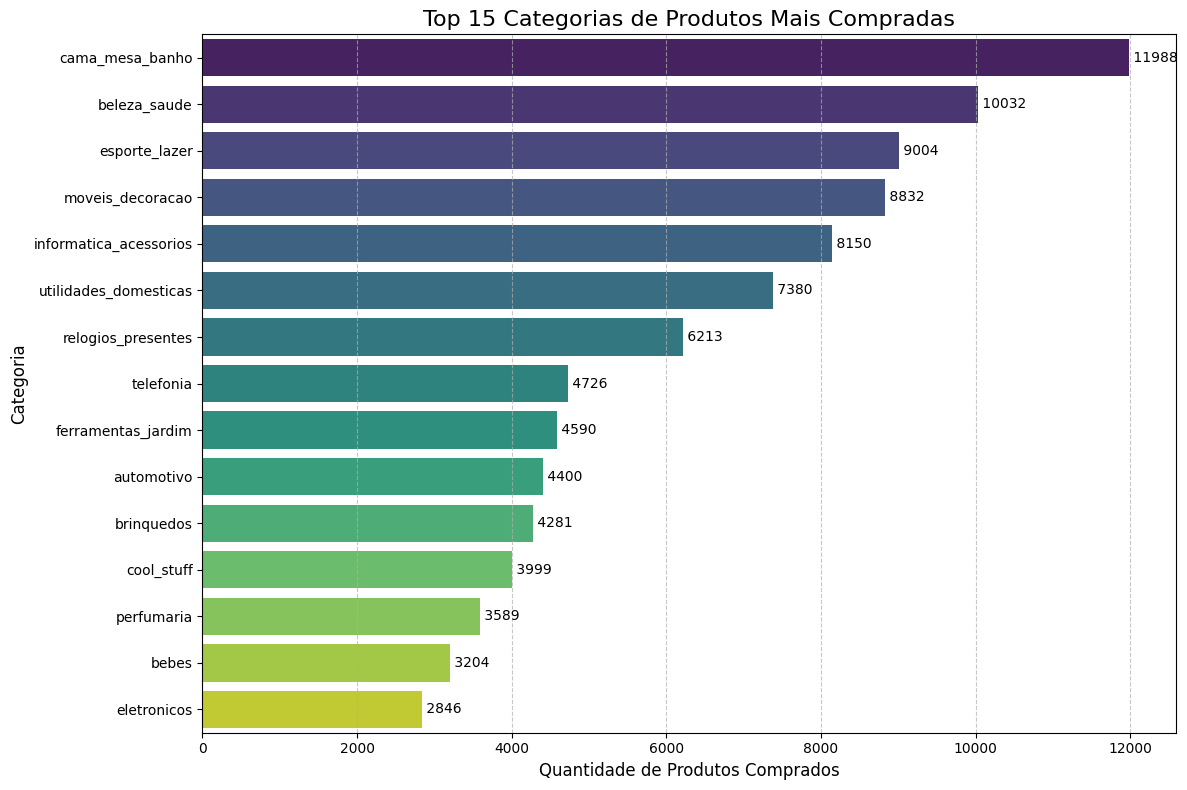

In [11]:
# Pegando as 15 categorias mais compradas
top_categories = df_train['product_category_name'].value_counts().head(15)

# Plotando um gráfico de barras horizontais para facilitar a leitura dos nomes das categorias
plt.figure(figsize=(12, 8))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 15 Categorias de Produtos Mais Compradas', fontsize=16)
plt.xlabel('Quantidade de Produtos Comprados', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Opcional: Adicionando os valores nas barras para melhor visualização
for index, value in enumerate(top_categories.values):
    plt.text(value, index, f' {value}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Tempo Médio de Entrega por Categoria

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\3629854117.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delivery_time_days', y='product_category_name', data=avg_delivery_por_cat, palette='coolwarm')


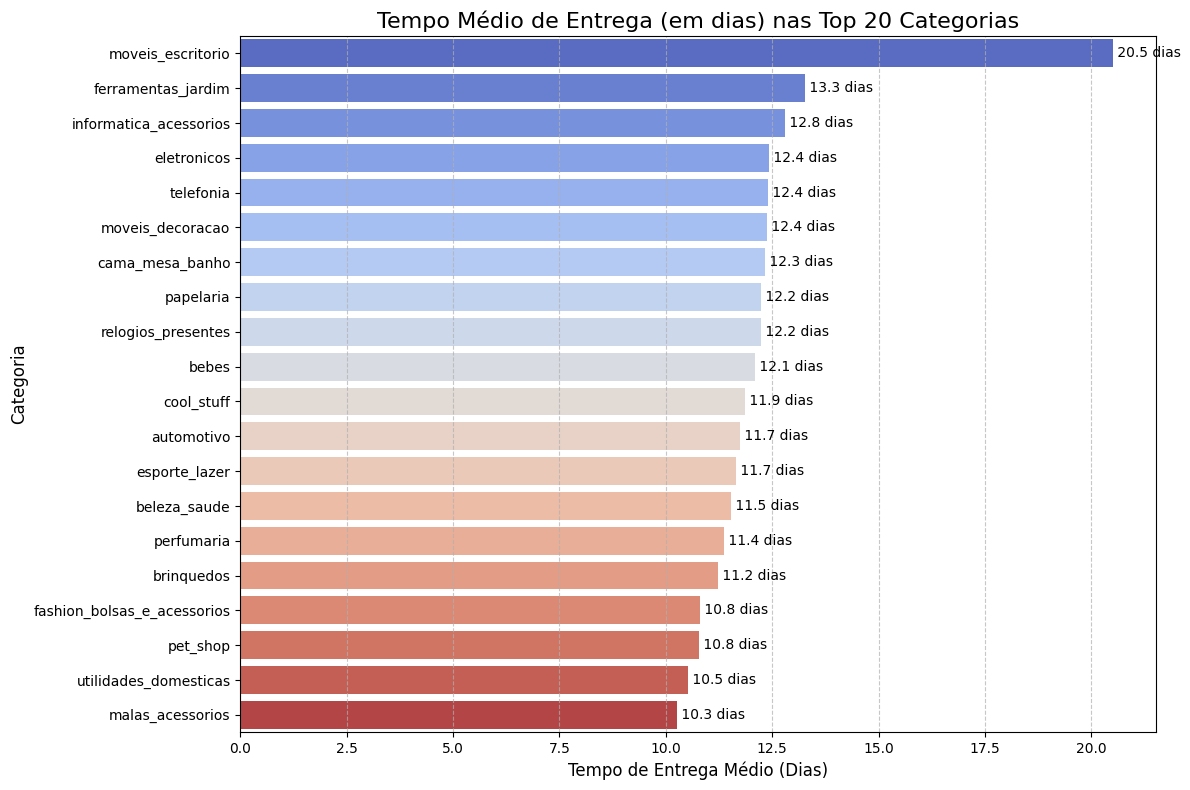

In [27]:
# Calculando o tempo total de entrega em dias (data de entrega - data de compra)
# (As colunas de datas já foram convertidas para datetime em células anteriores)
df_train['delivery_time_days'] = (df_train['order_delivered_customer_date'] - df_train['order_purchase_timestamp']).dt.days

# Removendo valores nulos (ou seja, pedidos sem data de entrega registrada)
df_delivery = df_train.dropna(subset=['delivery_time_days', 'product_category_name']).copy()

# Focando nas Top 20 categorias mais vendidas para manter a visualização clara
top_20_categorias = df_delivery['product_category_name'].value_counts().head(20).index
df_top_delivery = df_delivery[df_delivery['product_category_name'].isin(top_20_categorias)]

# Agrupando para pegar a MÉDIA de dias de entrega por categoria
avg_delivery_por_cat = df_top_delivery.groupby('product_category_name')['delivery_time_days'].mean().reset_index()
avg_delivery_por_cat.sort_values(by='delivery_time_days', ascending=False, inplace=True)

# Plotando o gráfico
plt.figure(figsize=(12, 8))
sns.barplot(x='delivery_time_days', y='product_category_name', data=avg_delivery_por_cat, palette='coolwarm')

plt.title('Tempo Médio de Entrega (em dias) nas Top 20 Categorias', fontsize=16)
plt.xlabel('Tempo de Entrega Médio (Dias)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionando os valores numéricos no gráfico
for index, value in enumerate(avg_delivery_por_cat['delivery_time_days']):
    plt.text(value, index, f' {value:.1f} dias', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Porcentagem de Atraso por Categoria de Produto

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\3954041944.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_delayed_pct', y='product_category_name', data=delay_por_cat, palette='Reds_r')


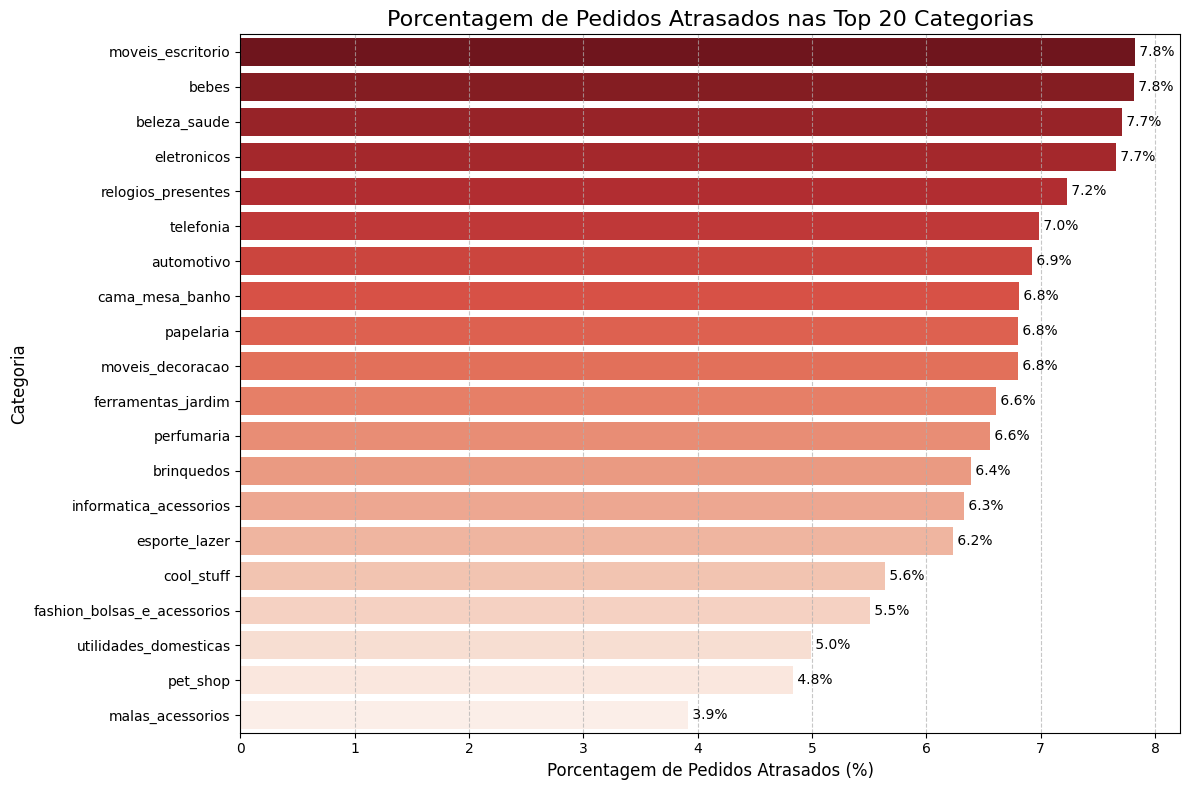

In [12]:
# Convertendo as colunas relacionadas a estimativa e entrega final para o formato datetime
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])
df_train['order_estimated_delivery_date'] = pd.to_datetime(df_train['order_estimated_delivery_date'])

# Removendo dados nulos nas datas (pedidos que não foram entregues ou falta info)
df_dates = df_train.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 'product_category_name']).copy()

# Criando variável do tempo de diferença em dias
# Valores > 0 indicam que a entrega ocorreu DEPOIS do prazo estimado (Atraso)
df_dates['delay_days'] = (df_dates['order_delivered_customer_date'] - df_dates['order_estimated_delivery_date']).dt.days

# Criando a flag para identificar atraso (booleano)
df_dates['is_delayed'] = df_dates['delay_days'] > 0

# Focando a análise nas Top 20 categorias mais vendidas para manter relevância estatística
top_20_categorias = df_dates['product_category_name'].value_counts().head(20).index
df_top_cats = df_dates[df_dates['product_category_name'].isin(top_20_categorias)]

# Agrupando por categoria para ver a proporção (média) de atrasos
delay_por_cat = df_top_cats.groupby('product_category_name')['is_delayed'].mean().reset_index()
delay_por_cat['is_delayed_pct'] = delay_por_cat['is_delayed'] * 100
delay_por_cat.sort_values(by='is_delayed_pct', ascending=False, inplace=True)

# Plotando
plt.figure(figsize=(12, 8))
sns.barplot(x='is_delayed_pct', y='product_category_name', data=delay_por_cat, palette='Reds_r')

plt.title('Porcentagem de Pedidos Atrasados nas Top 20 Categorias', fontsize=16)
plt.xlabel('Porcentagem de Pedidos Atrasados (%)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adicionando os valores numéricos no gráfico
for index, value in enumerate(delay_por_cat['is_delayed_pct']):
    plt.text(value, index, f' {value:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Quantidade de Compras por Dia da Semana

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\3292860415.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compras_por_dia, x='dia_semana', y='quantidade_compras', palette='Set2')


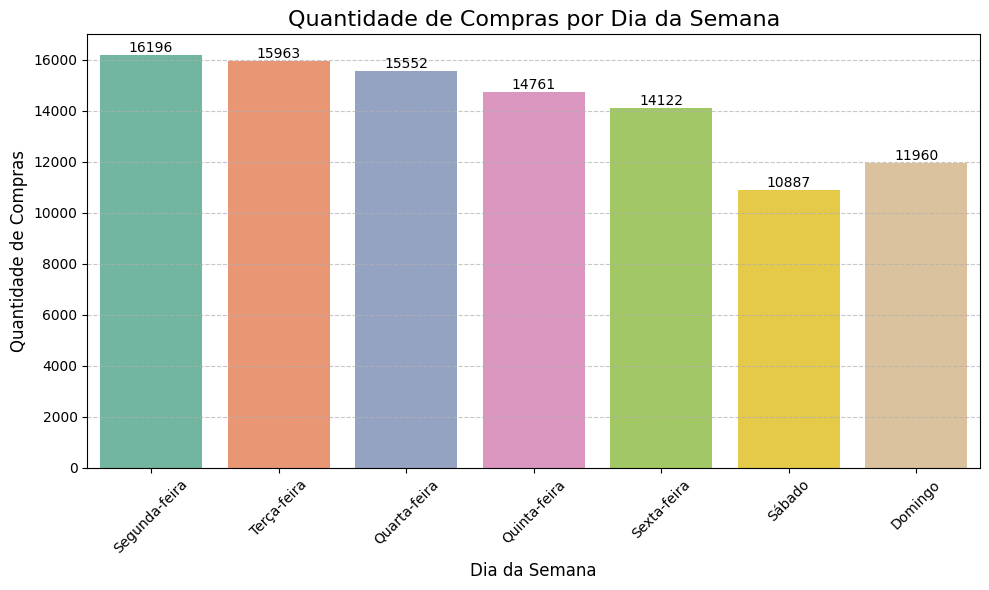

In [14]:
# Extraindo o nome do dia da semana (em inglês por padrão)
df_train['weekday'] = df_train['order_purchase_timestamp'].dt.day_name()

# Mapeando para o português para facilitar o entendimento
dias_semana_pt = {
    'Monday': 'Segunda-feira',
    'Tuesday': 'Terça-feira',
    'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira',
    'Friday': 'Sexta-feira',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df_train['dia_semana'] = df_train['weekday'].map(dias_semana_pt)

# Definindo a ordem cronológica correta dos dias para o gráfico
ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']

# Agrupando a quantidade de pedidos únicos por dia da semana
compras_por_dia = df_train.groupby('dia_semana')['order_id'].nunique().reindex(ordem_dias).reset_index()
compras_por_dia.rename(columns={'order_id': 'quantidade_compras'}, inplace=True)

# Plotando o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=compras_por_dia, x='dia_semana', y='quantidade_compras', palette='Set2')

plt.title('Quantidade de Compras por Dia da Semana', fontsize=16)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Quantidade de Compras', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os valores numéricos no topo de cada barra
for index, value in enumerate(compras_por_dia['quantidade_compras']):
    plt.text(index, value, f'{int(value)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Distância entre Vendedor e Cliente (Haversine)
Analisando o impacto da distância geográfica nos atrasos de entrega.

In [23]:
import math

# Função para calcular distância Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Raio da Terra em km
    if pd.isna(lat1) or pd.isna(lat2) or pd.isna(lon1) or pd.isna(lon2):
        return np.nan
        
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    return R * c

# Agrupando geolocalização por prefixo de CEP para remover duplicatas
geo_grouped = df_geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Merge com clientes
df_train = df_train.merge(
    geo_grouped, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
).rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
}).drop(columns='geolocation_zip_code_prefix')

# Merge com vendedores
df_train = df_train.merge(
    geo_grouped, 
    left_on='seller_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
).rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
}).drop(columns='geolocation_zip_code_prefix')

# Calculando a distância para cada pedido (usando vetorização ou apply, apply pode ser demorado mas ok com função lambda se as linhas não baterem milhões)
# Aplicando vetorização para performance:
lat1, lon1 = np.radians(df_train['customer_lat']), np.radians(df_train['customer_lng'])
lat2, lon2 = np.radians(df_train['seller_lat']), np.radians(df_train['seller_lng'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df_train['distance_km'] = 6371 * c

df_train[['customer_zip_code_prefix', 'seller_zip_code_prefix', 'distance_km']].head()

,customer_zip_code_prefix,seller_zip_code_prefix,distance_km
0,87502,9080.0,687.434185
1,35490,9080.0,417.139650
2,38600,9080.0,714.295670
3,24710,29156.0,389.663761
4,24710,29156.0,389.663761


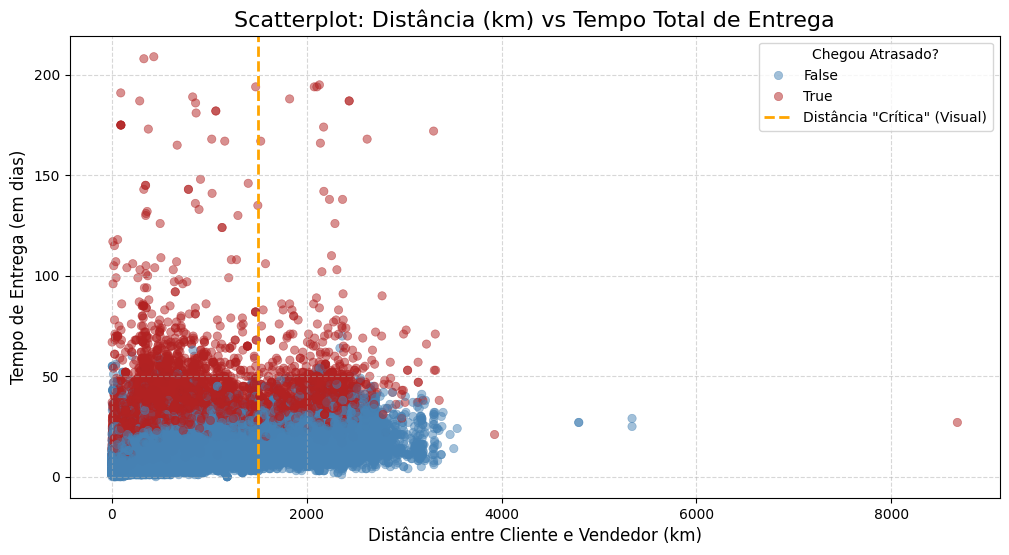

In [24]:
# Preparando dados de distâncias e tempo de entrega (em dias)
df_dist = df_train.dropna(subset=['distance_km', 'delivery_time_days']).copy()
df_dist['is_delayed'] = (df_dist['order_delivered_customer_date'] - df_dist['order_estimated_delivery_date']).dt.days > 0
df_dist['delay_days'] = (df_dist['order_delivered_customer_date'] - df_dist['order_estimated_delivery_date']).dt.days
df_dist['delay_days'] = df_dist['delay_days'].apply(lambda x: x if x > 0 else 0) # Ignorando entregas adiantadas para a correlação de atraso

# --- 1. Scatterplot Distância x Tempo de Entrega (Destacando Atrasos) ---
plt.figure(figsize=(12, 6))
# Para evitar sobrecarga, pegamos uma amostra ou usamos transparência
sns.scatterplot(
    data=df_dist, 
    x='distance_km', 
    y='delivery_time_days', 
    hue='is_delayed', 
    palette={False: 'steelblue', True: 'firebrick'},
    alpha=0.5,
    edgecolor=None
)
plt.title('Scatterplot: Distância (km) vs Tempo Total de Entrega', fontsize=16)
plt.xlabel('Distância entre Cliente e Vendedor (km)', fontsize=12)
plt.ylabel('Tempo de Entrega (em dias)', fontsize=12)
plt.axvline(x=1500, color='orange', linestyle='--', linewidth=2, label='Distância "Crítica" (Visual)')
plt.legend(title='Chegou Atrasado?')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Atrasos em Curtas Distâncias: Se houver muitos pontos vermelhos concentrados perto do quilômetro zero (mesma cidade ou estado), isso indica que o problema não é logístico rodoviário, mas sim operacional. Exemplo: Vendedor que demora para despachar o produto ou problemas de estoque.

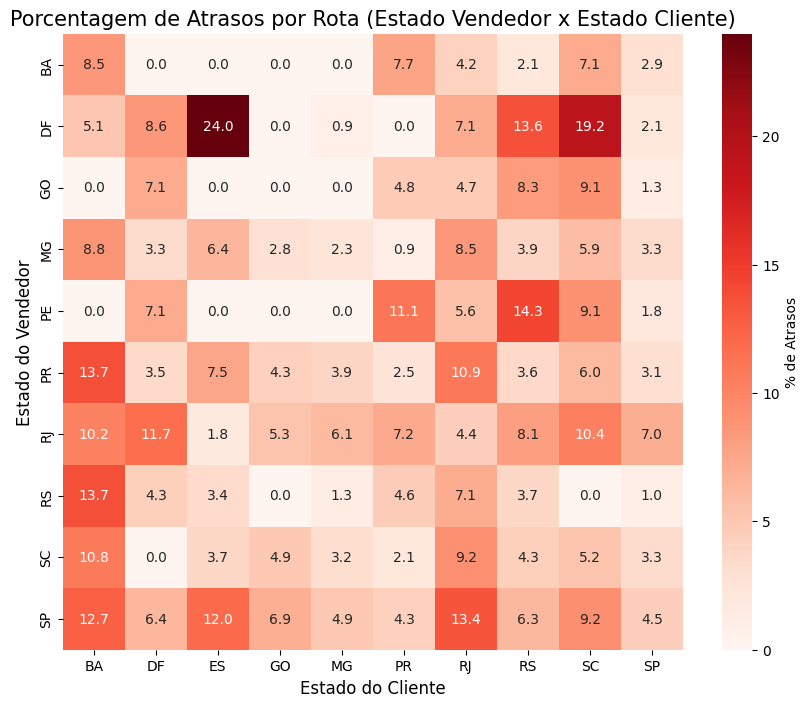

In [25]:
# --- 2. Heatmap: Porcentagem de Atrasos entre Estados (Vendedor -> Cliente) ---
# Filtrando estados com mais representatividade para o heatmap não ficar bagunçado
top_seller_states = df_dist['seller_state'].value_counts().head(10).index
top_customer_states = df_dist['customer_state'].value_counts().head(10).index

df_heatmap = df_dist[
    (df_dist['seller_state'].isin(top_seller_states)) & 
    (df_dist['customer_state'].isin(top_customer_states))
]

# Calculando a proporção de atrasos
heatmap_data = df_heatmap.groupby(['seller_state', 'customer_state'])['is_delayed'].mean().unstack() * 100

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt=".1f", cbar_kws={'label': '% de Atrasos'})
plt.title('Porcentagem de Atrasos por Rota (Estado Vendedor x Estado Cliente)', fontsize=15)
plt.ylabel('Estado do Vendedor', fontsize=12)
plt.xlabel('Estado do Cliente', fontsize=12)
plt.show()

* O "Vendedor Local": Você pode comparar se um cliente do Nordeste que compra de um vendedor do próprio Nordeste recebe mais rápido do que pedindo de SP.
* Identificação do Gargalo: Se a rota RJ -> SP possui mais atraso do que SP -> RJ (mesma distância), isso mostra ineficiência nas transportadoras saindo de um estado específico.

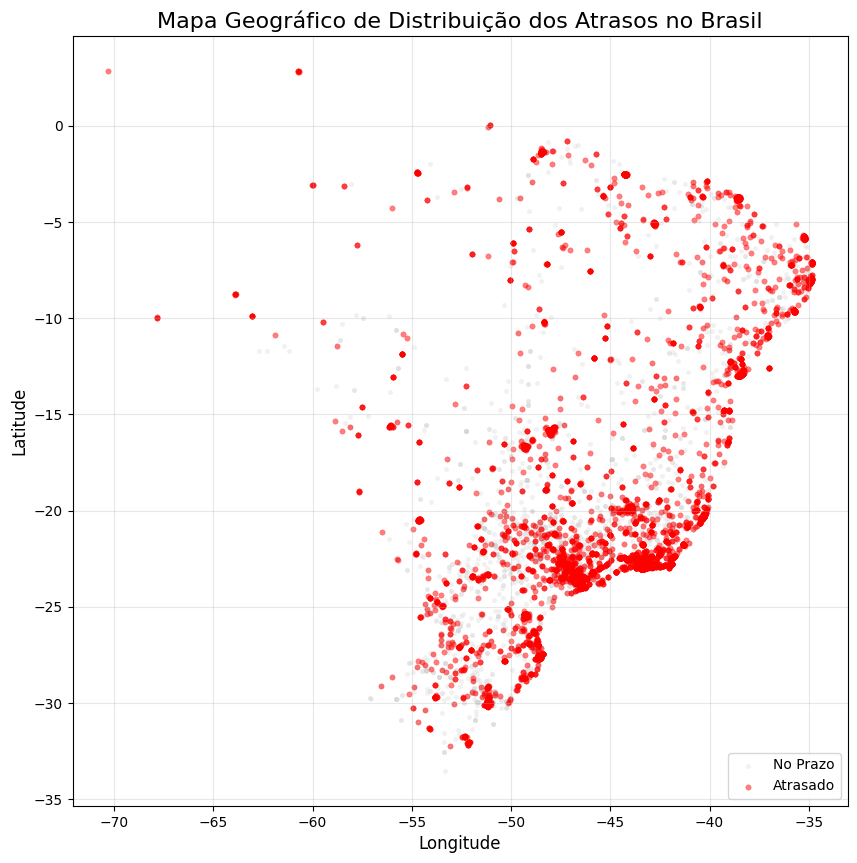

In [26]:
# --- 3. Mapa do Brasil (Atrasos por Localização do Cliente) ---
# Vamos plotar a geolocalização dos clientes e colorir as regiões onde mais se tem atraso.
# Limitando as coordenadas para a caixa (bounding box) do Brasil, excluindo outliers do dataset
box_br = {
    'lat_min': -33.7, 'lat_max': 5.2,
    'lng_min': -73.9, 'lng_max': -34.8
}

df_map = df_dist[
    (df_dist['customer_lat'] >= box_br['lat_min']) & (df_dist['customer_lat'] <= box_br['lat_max']) &
    (df_dist['customer_lng'] >= box_br['lng_min']) & (df_dist['customer_lng'] <= box_br['lng_max'])
]

plt.figure(figsize=(10, 10))

# Clientes que não tiveram atraso (em cinza claro, plotado como background)
sns.scatterplot(
    data=df_map[df_map['is_delayed'] == False].sample(frac=0.1, random_state=42), # 10% da amostra para renderizar rápido
    x='customer_lng', 
    y='customer_lat', 
    color='lightgray', 
    alpha=0.3,
    s=10,
    edgecolor=None,
    label='No Prazo'
)

# Clientes com atrasos (em vermelho, em cima)
sns.scatterplot(
    data=df_map[df_map['is_delayed'] == True], # Menos dados, plotar todos ou sample
    x='customer_lng', 
    y='customer_lat', 
    color='red', 
    alpha=0.5,
    s=15,
    edgecolor=None,
    label='Atrasado'
)

plt.title('Mapa Geográfico de Distribuição dos Atrasos no Brasil', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

* Litoral x Interior: Geralmente, entregas para as capitais litorâneas fluem bem, mas um leve desvio para o interior do Nordeste ou Norte revela um "mar vermelho". Isso reflete a dependência do transporte rodoviário e infraestrutura ruim de estradas.
* Cidades Isoladas: O mapa permite ver pequenas "ilhas de atraso", isoladas geograficamente. Revela onde o principal serviço de entrega do país (geralmente os Correios) sofre para cumprir os prazos estabelecidos.

## Impacto das Dimensões do Produto no Atraso
Análise de possíveis gargalos logísticos com base no peso (kg) e no volume (cm³) dos produtos enviados.

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\3699615855.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_peso = sns.barplot(data=contagem_peso, x='Faixa de Peso', y='Quantidade de Atrasos', palette='Oranges_r')


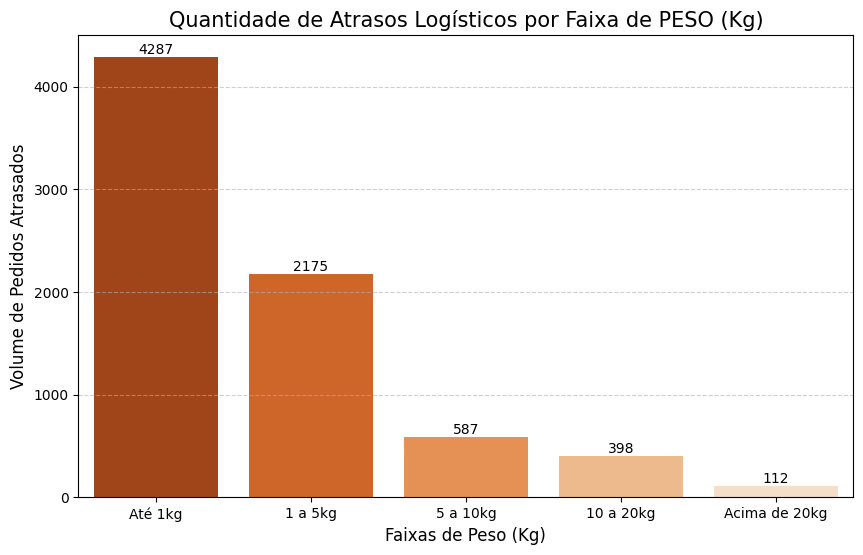

In [28]:
# --- 1. Atrasos pelo PESO do Produto ---

# Filtrando dados que possuem informação de peso e validando datas de entrega
df_dimensoes = df_train.dropna(subset=['product_weight_g', 'order_delivered_customer_date', 'order_estimated_delivery_date']).copy()

# Recalculando a flag de atraso para garantir
df_dimensoes['is_delayed'] = (df_dimensoes['order_delivered_customer_date'] - df_dimensoes['order_estimated_delivery_date']).dt.days > 0

# Limitando apenas para os pedidos que ATRASARAM
df_atrasados = df_dimensoes[df_dimensoes['is_delayed']].copy()

# Convertendo peso de gramas para kilogramas (kg)
df_atrasados['peso_kg'] = df_atrasados['product_weight_g'] / 1000

# Criando faixas (bins) de peso para categorizar
# Bins: 0 a 1kg, 1 a 5kg, 5 a 10kg, 10 a 20kg, acima de 20kg
bins_peso = [0, 1, 5, 10, 20, 1000]
labels_peso = ['Até 1kg', '1 a 5kg', '5 a 10kg', '10 a 20kg', 'Acima de 20kg']
df_atrasados['faixa_peso'] = pd.cut(df_atrasados['peso_kg'], bins=bins_peso, labels=labels_peso)

# Agrupando para o gráfico
contagem_peso = df_atrasados['faixa_peso'].value_counts().reindex(labels_peso).reset_index()
contagem_peso.columns = ['Faixa de Peso', 'Quantidade de Atrasos']

plt.figure(figsize=(10, 6))
grafico_peso = sns.barplot(data=contagem_peso, x='Faixa de Peso', y='Quantidade de Atrasos', palette='Oranges_r')

plt.title('Quantidade de Atrasos Logísticos por Faixa de PESO (Kg)', fontsize=15)
plt.xlabel('Faixas de Peso (Kg)', fontsize=12)
plt.ylabel('Volume de Pedidos Atrasados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionando os números exatos nas barras
for index, row in contagem_peso.iterrows():
    grafico_peso.text(index, row['Quantidade de Atrasos'], int(row['Quantidade de Atrasos']), color='black', ha="center", va="bottom")

plt.show()

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\2194472152.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_vol = sns.barplot(data=contagem_vol, x='Faixa de Volume', y='Quantidade de Atrasos', palette='Purples_r')


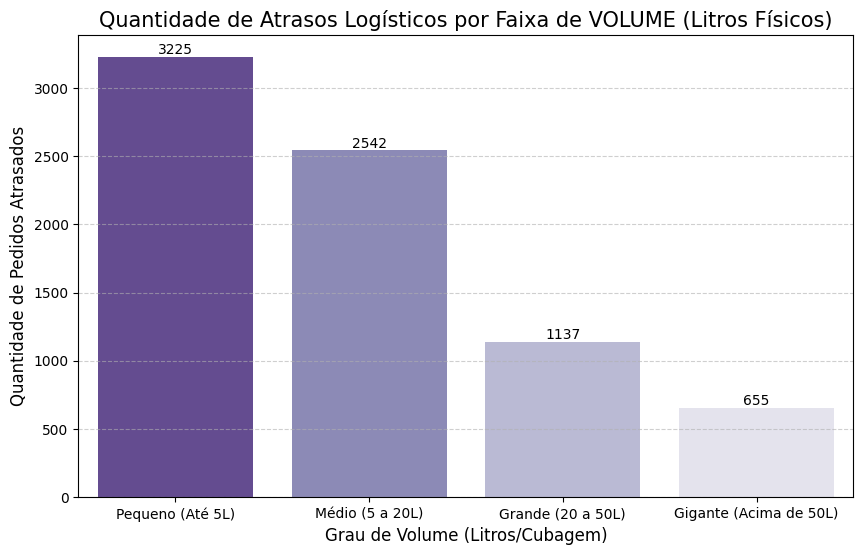

In [29]:
# --- 2. Atrasos pelo VOLUME (Tamanho) do Produto ---

# Removendo nulos nas medidas físicas
df_atrasados_vol = df_atrasados.dropna(subset=['product_length_cm', 'product_height_cm', 'product_width_cm']).copy()

# Calculando o Volume Cúbico em cm³ (Comprimento * Altura * Largura)
df_atrasados_vol['volume_cm3'] = df_atrasados_vol['product_length_cm'] * df_atrasados_vol['product_height_cm'] * df_atrasados_vol['product_width_cm']

# Convertendo para Litros volumétricos (1 Litro = 1000 cm³ aprox) para facilitar a interpretação
df_atrasados_vol['volume_litros'] = df_atrasados_vol['volume_cm3'] / 1000

# Criando faixas de volume
# Ex: Até 5L (pacotes pequenos como roupas/acessórios), 5 a 20L (médios como eletrônicos/calçados), 
# 20 a 50L (grandes como microondas), acima de 50L (gigantes como tvs, móveis)
bins_vol = [0, 5, 20, 50, 1000]
labels_vol = ['Pequeno (Até 5L)', 'Médio (5 a 20L)', 'Grande (20 a 50L)', 'Gigante (Acima de 50L)']
df_atrasados_vol['faixa_volume'] = pd.cut(df_atrasados_vol['volume_litros'], bins=bins_vol, labels=labels_vol)

contagem_vol = df_atrasados_vol['faixa_volume'].value_counts().reindex(labels_vol).reset_index()
contagem_vol.columns = ['Faixa de Volume', 'Quantidade de Atrasos']

plt.figure(figsize=(10, 6))
grafico_vol = sns.barplot(data=contagem_vol, x='Faixa de Volume', y='Quantidade de Atrasos', palette='Purples_r')

plt.title('Quantidade de Atrasos Logísticos por Faixa de VOLUME (Litros Físicos)', fontsize=15)
plt.xlabel('Grau de Volume (Litros/Cubagem)', fontsize=12)
plt.ylabel('Quantidade de Pedidos Atrasados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adicionando os números exatos nas barras
for index, row in contagem_vol.iterrows():
    grafico_vol.text(index, row['Quantidade de Atrasos'], int(row['Quantidade de Atrasos']), color='black', ha="center", va="bottom")

plt.show()

## Análise Financeira do Frete vs Logística
Como o preço do frete se relaciona com a distância percorrida, o tempo de entrega e a taxa de atrasos?

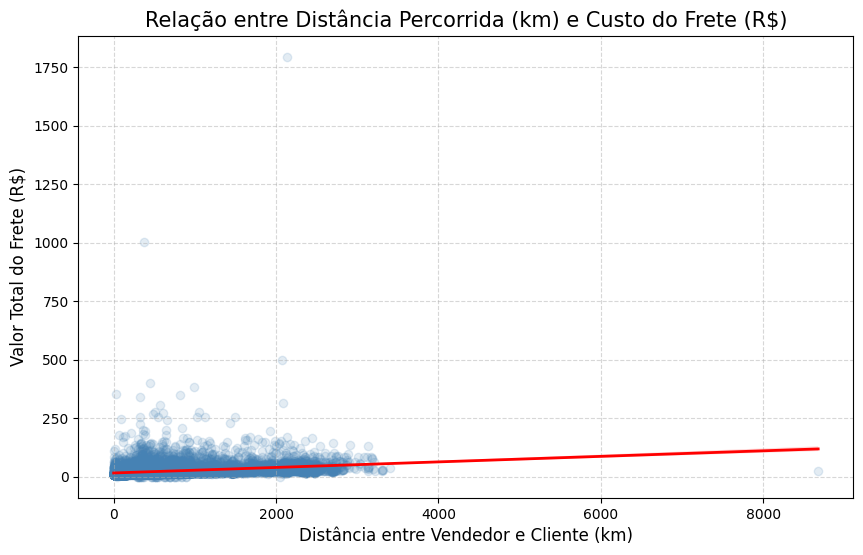

In [30]:
# Preparando a base para as análises de frete
# Precisamos dropar itens duplicados causados pelos merges anteriores, para não inflar o valor do frete do pedido
df_frete = df_train.drop_duplicates(subset=['order_id', 'order_item_id']).copy()

# Somando o frete de todos os itens do mesmo pedido para ter o "Frete Total Pago no Carrinho"
df_frete_pedido = df_frete.groupby('order_id').agg({
    'freight_value': 'sum',
    'distance_km': 'first',
    'delivery_time_days': 'first',
    'is_delayed': 'first'
}).dropna()

# Extraindo uma amostra de 15% para os scatterplots não ficarem travados/poluídos 
# (pois são milhares de pontos no dataset do Olist)
amostra_frete = df_frete_pedido.sample(frac=0.15, random_state=42)

# --- 1. Relação: Frete x Distância ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=amostra_frete, 
    x='distance_km', 
    y='freight_value', 
    scatter_kws={'alpha': 0.15, 'color': 'steelblue'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Relação entre Distância Percorrida (km) e Custo do Frete (R$)', fontsize=15)
plt.xlabel('Distância entre Vendedor e Cliente (km)', fontsize=12)
plt.ylabel('Valor Total do Frete (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

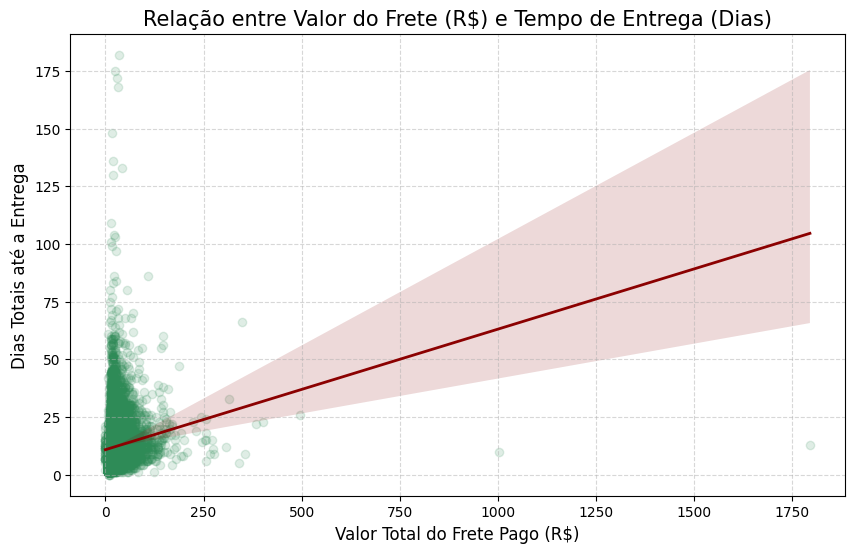

In [31]:
# --- 2. Relação: Frete x Tempo de Entrega (Mais caro entrega mais rápido?) ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=amostra_frete, 
    x='freight_value', 
    y='delivery_time_days', 
    scatter_kws={'alpha': 0.15, 'color': 'seagreen'}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.title('Relação entre Valor do Frete (R$) e Tempo de Entrega (Dias)', fontsize=15)
plt.xlabel('Valor Total do Frete Pago (R$)', fontsize=12)
plt.ylabel('Dias Totais até a Entrega', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Altos valores de frete não são "taxas de urgência", mas sim reflexo de complexidade. Eles indicam que o produto é muito pesado/volumoso ou que o destino é extremamente remoto (Norte/Nordeste ou interior profundo). Consequentemente, essas limitações geográficas e de peso forçam a encomenda a passar por malhas logísticas mais lentas (como balsas e caminhões pesados).

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\448000016.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_atraso_frete = sns.barplot(


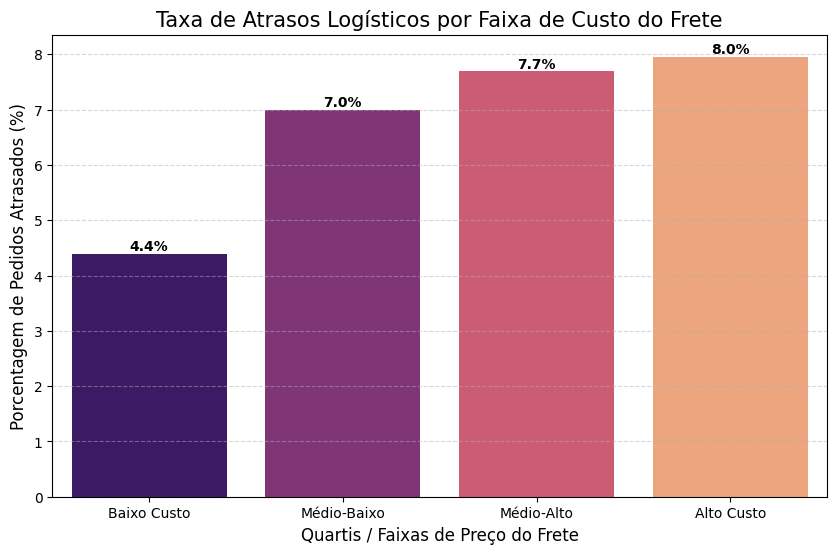

In [32]:
# --- 3. Relação: Frete Barato aumenta as chances de Atraso? ---

# Vamos agrupar todo o volume de fretes do E-commerce em 4 partes estatísticas iguais (Quartis)
df_frete_pedido['faixa_custo_frete'] = pd.qcut(
    df_frete_pedido['freight_value'], 
    q=4, 
    labels=['Baixo Custo', 'Médio-Baixo', 'Médio-Alto', 'Alto Custo']
)

# Calculando a métrica de Atrasos (Média da flag booleana nos dá a % exata)
atraso_por_frete = df_frete_pedido.groupby('faixa_custo_frete')['is_delayed'].mean().reset_index()
atraso_por_frete['is_delayed_pct'] = atraso_por_frete['is_delayed'] * 100

plt.figure(figsize=(10, 6))
grafico_atraso_frete = sns.barplot(
    data=atraso_por_frete, 
    x='faixa_custo_frete', 
    y='is_delayed_pct', 
    palette='magma'
)

plt.title('Taxa de Atrasos Logísticos por Faixa de Custo do Frete', fontsize=15)
plt.xlabel('Quartis / Faixas de Preço do Frete', fontsize=12)
plt.ylabel('Porcentagem de Pedidos Atrasados (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionando os números exatos nas barras para visibilidade
for index, row in atraso_por_frete.iterrows():
    grafico_atraso_frete.text(
        index, 
        row['is_delayed_pct'], 
        f"{row['is_delayed_pct']:.1f}%", 
        color='black', 
        ha="center", 
        va="bottom",
        fontweight='bold'
    )

plt.show()

Fretes da categoria "Baixo Custo" geralmente significam viagens expressas locais (Ex: Vendedor de SP entregando para Cliente em SP Capital de motoboy), pacotes minúsculos (roupas/capinhas) e rotas altamente pavimentadas. O frete de "Alto Custo" embute a imprevisibilidade estrutural do Brasil (chuvas que bloqueiam estradas não asfaltadas, fiscalização fiscal estadual demorada na fronteira dos Estados e dificuldade de transbordo de cargas gigantes).

## Impacto das Estimativas de Entrega (SLA)
Pedidos com promessas de entrega muito agressivas/curtas têm maior taxa de falha (atraso)?

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\4072902111.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_sla = sns.barplot(


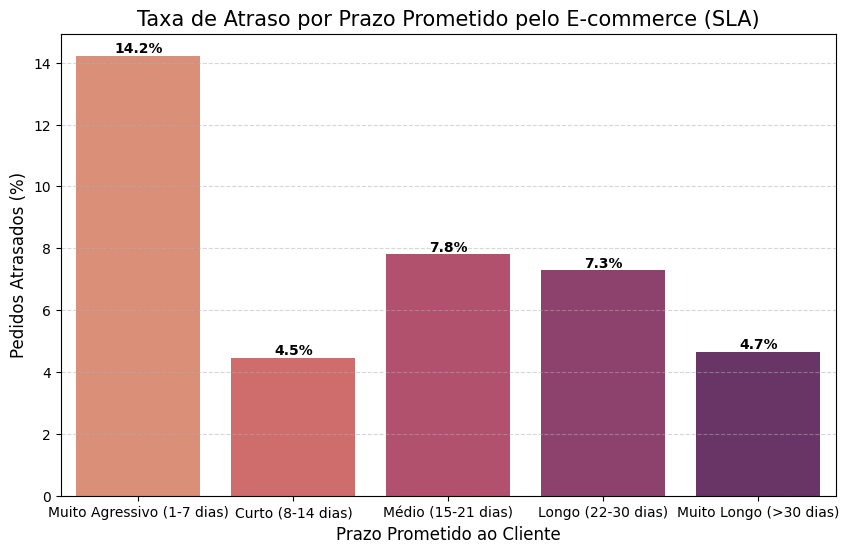

In [33]:
# Preparando os dados: removendo duplicatas para calcular por pedido
df_sla = df_train.drop_duplicates(subset=['order_id']).dropna(
    subset=['order_estimated_delivery_date', 'order_purchase_timestamp', 'order_delivered_customer_date']
).copy()

# Calculando o SLA Prometido em dias (Estimativa de Entrega dada ao cliente na hora da compra)
df_sla['sla_prometido_dias'] = (df_sla['order_estimated_delivery_date'] - df_sla['order_purchase_timestamp']).dt.days

# Filtrar apenas SLAs válidos (maiores que 0)
df_sla = df_sla[df_sla['sla_prometido_dias'] > 0]

# Recalculando flag de atraso
df_sla['is_delayed'] = (df_sla['order_delivered_customer_date'] - df_sla['order_estimated_delivery_date']).dt.days > 0

# Classificando as estimativas em blocos gerenciais
bins_sla = [0, 7, 14, 21, 30, 200]
labels_sla = ['Muito Agressivo (1-7 dias)', 'Curto (8-14 dias)', 'Médio (15-21 dias)', 'Longo (22-30 dias)', 'Muito Longo (>30 dias)']
df_sla['faixa_sla'] = pd.cut(df_sla['sla_prometido_dias'], bins=bins_sla, labels=labels_sla)

# Calculando a Taxa (%) de Atraso por Faixa
taxa_atraso_sla = df_sla.groupby('faixa_sla')['is_delayed'].mean().reset_index()
taxa_atraso_sla['is_delayed_pct'] = taxa_atraso_sla['is_delayed'] * 100

# Plotando Gráfico de Barras: Falhas por Agressividade do SLA
plt.figure(figsize=(10, 6))
grafico_sla = sns.barplot(
    data=taxa_atraso_sla, 
    x='faixa_sla', 
    y='is_delayed_pct', 
    palette='flare'
)

plt.title('Taxa de Atraso por Prazo Prometido pelo E-commerce (SLA)', fontsize=15)
plt.xlabel('Prazo Prometido ao Cliente', fontsize=12)
plt.ylabel('Pedidos Atrasados (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionando rótulos nas barras
for index, row in taxa_atraso_sla.iterrows():
    grafico_sla.text(
        index, 
        row['is_delayed_pct'], 
        f"{row['is_delayed_pct']:.1f}%", 
        color='black', 
        ha="center", 
        va="bottom",
        fontweight='bold'
    )
plt.show()

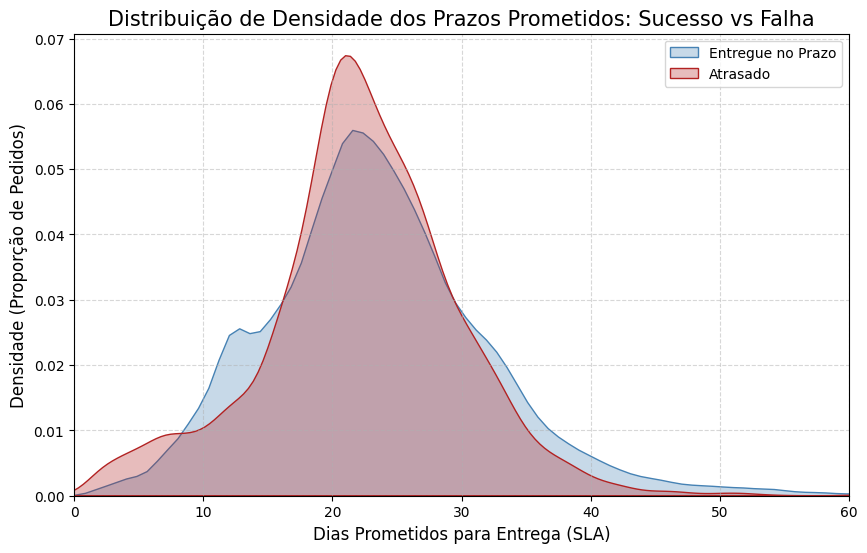

In [34]:
# Gráfico Adicional: Densidade (KDE) comparando Promessas Cumpridas x Atrasadas
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_sla[df_sla['is_delayed'] == False], 
    x='sla_prometido_dias', 
    label='Entregue no Prazo', 
    color='steelblue', 
    fill=True, 
    alpha=0.3
)
sns.kdeplot(
    data=df_sla[df_sla['is_delayed'] == True], 
    x='sla_prometido_dias', 
    label='Atrasado', 
    color='firebrick', 
    fill=True, 
    alpha=0.3
)

plt.xlim(0, 60) # Focando nos primeiros 60 dias para melhor visualização
plt.title('Distribuição de Densidade dos Prazos Prometidos: Sucesso vs Falha', fontsize=15)
plt.xlabel('Dias Prometidos para Entrega (SLA)', fontsize=12)
plt.ylabel('Densidade (Proporção de Pedidos)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Sellers Problemáticos e Gargalos de Last Mile
Separando o tempo de responsabilidade do lojista (postagem) do tempo da transportadora (trânsito logístico).

In [35]:
# Convertendo as novas colunas de data que precisamos usar para datetime
df_train['order_approved_at'] = pd.to_datetime(df_train['order_approved_at'])
df_train['order_delivered_carrier_date'] = pd.to_datetime(df_train['order_delivered_carrier_date'])
df_train['order_delivered_customer_date'] = pd.to_datetime(df_train['order_delivered_customer_date'])

# 1. Calculando o Seller Handling Time (Tempo que o vendedor leva para postar o produto)
df_train['seller_handling_time'] = (df_train['order_delivered_carrier_date'] - df_train['order_approved_at']).dt.days

# 2. Calculando o Carrier Transit Time (Tempo que a transportadora leva para entregar após a postagem)
df_train['carrier_transit_time'] = (df_train['order_delivered_customer_date'] - df_train['order_delivered_carrier_date']).dt.days

# Limpando nulos temporariamente para não distorcer as métricas
df_perf = df_train.dropna(subset=['seller_id', 'seller_handling_time', 'carrier_transit_time']).copy()

# Recalculando is_delayed caso precise
df_perf['is_delayed'] = (df_perf['order_delivered_customer_date'] - df_perf['order_estimated_delivery_date']).dt.days > 0

# Agrupando pelo ID do Vendedor
seller_stats = df_perf.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_handling_time=('seller_handling_time', 'mean'),
    avg_carrier_time=('carrier_transit_time', 'mean'),
    delay_rate=('is_delayed', 'mean')
)

# Filtro de relevância: Apenas lojistas com pelo menos 30 pedidos na plataforma 
# (isso evita que um lojista que vendeu 1 produto e atrasou apareça com 100% de taxa de erro)
seller_stats_filtered = seller_stats[seller_stats['total_orders'] >= 30].copy()
seller_stats_filtered['delay_rate_pct'] = seller_stats_filtered['delay_rate'] * 100

print(f"Total de Sellers analisados após o filtro (>30 pedidos): {len(seller_stats_filtered)}")

Total de Sellers analisados após o filtro (>30 pedidos): 627


C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\610620070.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_delayed_sellers['delay_rate_pct'], y=short_ids, palette='Reds_r')


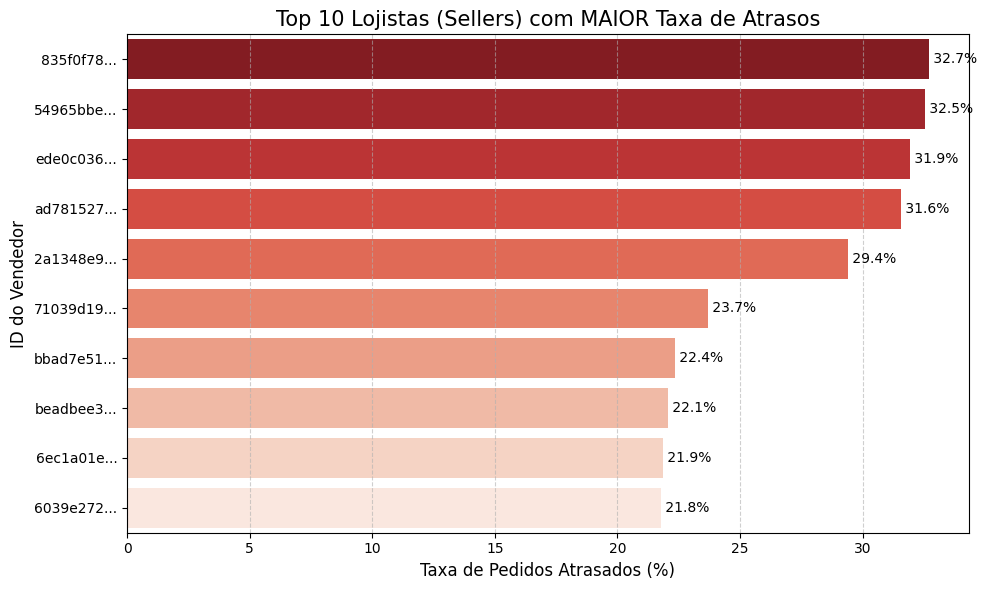

In [36]:
# --- Gráfico 1: TOP 10 Sellers - Taxa de Atraso ---
top_delayed_sellers = seller_stats_filtered.sort_values('delay_rate_pct', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Convertendo o index (ID do lojista) para string e cortando para caber bonito no gráfico (são IDs gigantes)
short_ids = [str(x)[:8] + '...' for x in top_delayed_sellers.index]

sns.barplot(x=top_delayed_sellers['delay_rate_pct'], y=short_ids, palette='Reds_r')
plt.title('Top 10 Lojistas (Sellers) com MAIOR Taxa de Atrasos', fontsize=15)
plt.xlabel('Taxa de Pedidos Atrasados (%)', fontsize=12)
plt.ylabel('ID do Vendedor', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Labels
for index, value in enumerate(top_delayed_sellers['delay_rate_pct']):
    plt.text(value, index, f" {value:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\1393297569.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_slow_sellers['avg_handling_time'], y=short_ids_slow, palette='Oranges_r')


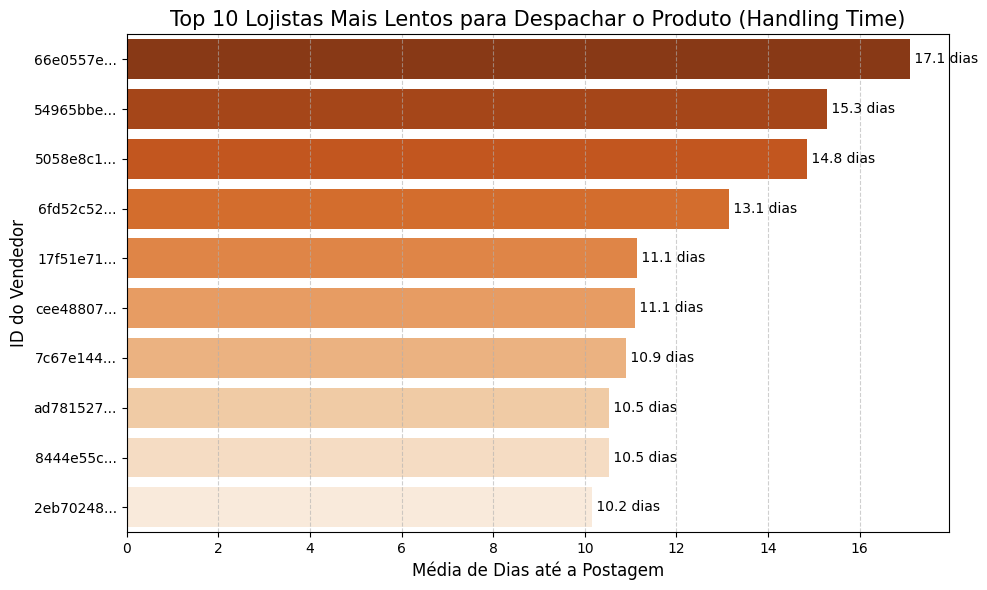

In [37]:
# --- Gráfico 2: TOP 10 Sellers - Lentidão para Postar ---
top_slow_sellers = seller_stats_filtered.sort_values('avg_handling_time', ascending=False).head(10)

plt.figure(figsize=(10, 6))
short_ids_slow = [str(x)[:8] + '...' for x in top_slow_sellers.index]

sns.barplot(x=top_slow_sellers['avg_handling_time'], y=short_ids_slow, palette='Oranges_r')
plt.title('Top 10 Lojistas Mais Lentos para Despachar o Produto (Handling Time)', fontsize=15)
plt.xlabel('Média de Dias até a Postagem', fontsize=12)
plt.ylabel('ID do Vendedor', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Labels
for index, value in enumerate(top_slow_sellers['avg_handling_time']):
    plt.text(value, index, f" {value:.1f} dias", va='center', fontsize=10)

plt.tight_layout()
plt.show()

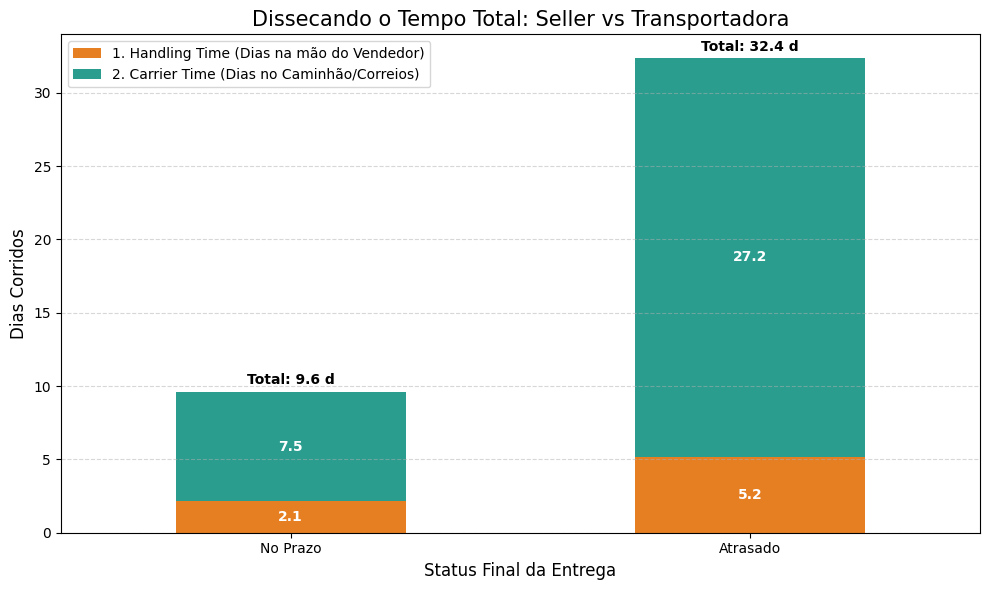

In [38]:
# --- Gráfico 3: Decomposição do Tempo (Culpa do Vendedor vs Culpa da Transportadora) ---
# Vamos descobrir de quem é a culpa quando o pedido chega fora do prazo

time_split = df_perf.groupby('is_delayed')[['seller_handling_time', 'carrier_transit_time']].mean().reset_index()
time_split['is_delayed'] = time_split['is_delayed'].map({False: 'No Prazo', True: 'Atrasado'})
time_split.set_index('is_delayed', inplace=True)

# Plotando como gráfico de barras empilhadas (Stacked Bar Chart)
ax = time_split.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e67e22', '#2a9d8f'])

plt.title('Dissecando o Tempo Total: Seller vs Transportadora', fontsize=15)
plt.ylabel('Dias Corridos', fontsize=12)
plt.xlabel('Status Final da Entrega', fontsize=12)
plt.legend(['1. Handling Time (Dias na mão do Vendedor)', '2. Carrier Time (Dias no Caminhão/Correios)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionando visualmente o total de dias no topo da barra
for i, (idx, row) in enumerate(time_split.iterrows()):
    total_dias = row['seller_handling_time'] + row['carrier_transit_time']
    # Texto do tempo do seller
    ax.text(i, row['seller_handling_time']/2, f"{row['seller_handling_time']:.1f}", ha='center', va='center', color='white', fontweight='bold')
    # Texto do tempo da Transportadora
    ax.text(i, row['seller_handling_time'] + (row['carrier_transit_time']/2), f"{row['carrier_transit_time']:.1f}", ha='center', va='center', color='white', fontweight='bold')
    # Total
    ax.text(i, total_dias + 0.5, f"Total: {total_dias:.1f} d", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusões da Análise de Gargalos Logísticos

1. **Problemas Pontuais com Lojistas (Sellers):** 
   - Ao observar o Top 10 de lojistas com maior taxa de atraso, notamos que existem _sellers_ (com volume estatístico relevante, >30 pedidos) onde o atraso na entrega é quase uma certeza para o consumidor.
   - Da mesma forma, há fornecedores que retêm a mercadoria internamente por quase ou mais de uma semana (Handling Time alto) antes de sequer entregarem o pacote aos correios/transportadora (fase de Last Mile). Isso evidencia problemas na operação e logística de armazenagem e empacotamento (`pick and pack`) do próprio parceiro (dropshipping ineficiente, falta de estoque real, etc).

2. **Decomposição da "Culpa" (Seller vs Carrier):**
   - Através do gráfico de barras empilhadas, dissecamos a linha do tempo da entrega desde o pagamento aprovado. 
   - Fica claro que, embora o **tempo da transportadora (Carrier Time)** seja, em valor absoluto, sempre a maior parcela da viagem, quando olhamos especificamente para o grupo de entregas **Atrasadas**, o **proporcional de lentidão aumenta acentuadamente do lado do vendedor**.
   - O tempo de retenção pelo vendedor ("_handling time_") cresce visivelmente nos casos que terminarão em frustração do cliente, indicando que a transportadora muitas vezes não consegue compensar na pista a demora inicial na expedição da caixa. Portanto, exigir regras de SLA interno mais duras _(ex: postar o pacote em no máximo 2 dias)_ para os *sellers* da plataforma pode ter um peso gigante na redução global de atrasos na Olist.

C:\Users\Sofhia\AppData\Local\Temp\ipykernel_19032\2600305226.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_handling = sns.barplot(


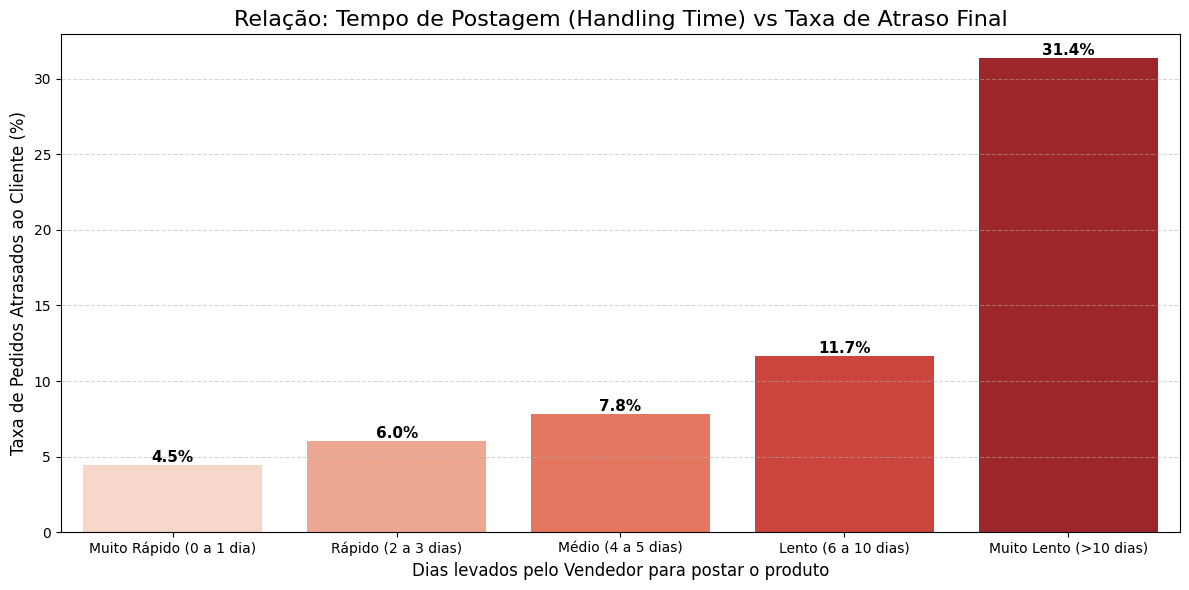

In [39]:
# --- Gráfico 4: Impacto do Tempo de Postagem no Atraso da Entrega ---
# Analisando se demorar muito para postar aumenta a chance de o pedido chegar atrasado

# Criando faixas (bins) para o tempo de postagem do vendedor (Handling Time)
bins_handling = [-1, 1, 3, 5, 10, 200]
labels_handling = ['Muito Rápido (0 a 1 dia)', 'Rápido (2 a 3 dias)', 'Médio (4 a 5 dias)', 'Lento (6 a 10 dias)', 'Muito Lento (>10 dias)']

# Copiando df_perf para não alterar análises anteriores
df_impacto = df_perf.copy()
df_impacto['faixa_handling'] = pd.cut(df_impacto['seller_handling_time'], bins=bins_handling, labels=labels_handling)

# Calculando a taxa de atraso por faixa de handling time
handling_impact = df_impacto.groupby('faixa_handling', observed=False)['is_delayed'].mean().reset_index()
handling_impact['is_delayed_pct'] = handling_impact['is_delayed'] * 100

plt.figure(figsize=(12, 6))
grafico_handling = sns.barplot(
    data=handling_impact, 
    x='faixa_handling', 
    y='is_delayed_pct', 
    palette='Reds'
)

plt.title('Relação: Tempo de Postagem (Handling Time) vs Taxa de Atraso Final', fontsize=16)
plt.xlabel('Dias levados pelo Vendedor para postar o produto', fontsize=12)
plt.ylabel('Taxa de Pedidos Atrasados ao Cliente (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionando os rótulos de porcentagem
for index, row in handling_impact.iterrows():
    grafico_handling.text(
        index, 
        row['is_delayed_pct'], 
        f"{row['is_delayed_pct']:.1f}%", 
        color='black', 
        ha="center", 
        va="bottom",
        fontweight='bold',
        fontsize=11
    )

plt.tight_layout()
plt.show()

**Conclusão sobre o Gráfico Acima:**
Fica muito nítido que a agilidade do lojista é um *driver* fundamental de sucesso ou falha no modelo de marketplace.
* Pedidos despachados muito rápido (até 1 dia) mantêm uma taxa de atraso final baixíssima, sugerindo que a transportadora raramente falha a ponto de extrapolar o SLA caso receba o pacote cedo.
* Por outro lado, lojistas que demoram **mais de 10 dias** para postar condenam o pedido ao atraso final em uma parcela massiva das ocorrências. A transportadora raramente tem capacidade de recuperar o tempo perdido na esteira logística inicial.

## Impacto do Atraso na Avaliação (Review Score)
Vamos verificar em mapa de calor (heatmap) exatamente como um atraso na entrega penaliza a nota final que o cliente deixa para o pedido.

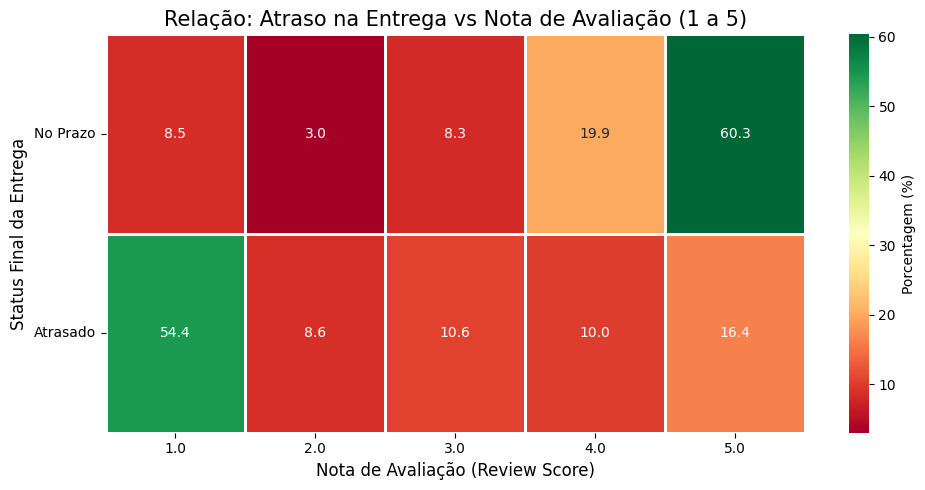

In [40]:
# Removendo dados nulos para esta análise específica
df_review_delay = df_train.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score']).copy()

# Calculando novamente a flag de atraso por segurança
df_review_delay['is_delayed'] = (df_review_delay['order_delivered_customer_date'] - df_review_delay['order_estimated_delivery_date']).dt.days > 0

# Convertendo True/False para labels legíveis
df_review_delay['Status da Entrega'] = df_review_delay['is_delayed'].map({False: 'No Prazo', True: 'Atrasado'})

# Criando a tabela cruzada (Crosstab) normalizada pelas linhas (índice)
# Isso nos dará a distribuição percentual das notas dentro das categorias "Atrasado" e "No Prazo"
ct_reviews = pd.crosstab(df_review_delay['Status da Entrega'], df_review_delay['review_score'], normalize='index') * 100

# Ordenando o eixo vertical para deixar "No Prazo" em cima e "Atrasado" embaixo
ct_reviews = ct_reviews.reindex(['No Prazo', 'Atrasado'])

plt.figure(figsize=(10, 5))
# A paleta RdYlGn (Red-Yellow-Green) faz muito sentido aqui para notas (1=Vermelho a 5=Verde)
sns.heatmap(ct_reviews, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': 'Porcentagem (%)'}, linewidths=1)

plt.title('Relação: Atraso na Entrega vs Nota de Avaliação (1 a 5)', fontsize=15)
plt.xlabel('Nota de Avaliação (Review Score)', fontsize=12)
plt.ylabel('Status Final da Entrega', fontsize=12)

# Rotacionando os labels de Y para leitura facilitada
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Interpretação do Mapa de Calor:**
- Ao analisar os pedidos que chegam **No Prazo**, a vasta maioria recebe notas 4 ou 5, mostrando alta satisfação com o cumprimento do combinado.
- Quando o pedido está **Atrasado**, o calor do mapa migra de forma drástica e instantânea para as notas 1. Isso comprova que o consumidor brasileiro do E-commerce não tolera quebra de SLA, punindo severamente a reputação da loja sempre que a encomenda atrasa.